# Практическая работа 1. Подготовка данных 
**Цель работы**:
Освоить полный цикл предварительной обработки табличных данных: от загрузки сырого датасета до формирования финальной матрицы признаков, пригодной для подачи в модель машинного обучения.  

В качестве примера используется основной файл соревнования:  
https://www.kaggle.com/competitions/home-credit-default-risk/data  

При желании можете найти и использовать другой датасет. Главное условие: наличие пропусков и шумовых значений в наборе данных. То есть ваш набор данных должен нуждаться в предварительной обработке. Желательно использовать датасет для соревнований.  
Обратите внимание на таблицу `HomeCredit_columns_description.csv` с описанием столбцов. 
 
Работу можно условно разделить на два этапа: анализ данных и построение пайплайна на его основе. Пайплайн (pipeline) представляет собой автоматизированную последовательность шагов, которые проходят данные для достижения конечного результата. В наборе данных присутствуют две ключевые таблицы: `application_test.csv` и `application_train.csv`. Опираясь на результаты анализа `application_train.csv`, необходимо сформировать набор команд, который обеспечит аналогичную подготовку данных из `application_test.csv`.  

Этап анализа
На этом этапе мы предпринимаем следующие действия:
- Смотрим на размер данных, типы переменных (числовые, категориальные).
- Считаем описательные статистики: среднее, медиана, минимум, максимум, квартили.
- Визуализируем: гистограммы, boxplot, scatter plot, матрица корреляций, pairplot.
- Анализируем целевую переменную: распределение, дисбаланс классов.
- Ищем пропуски и выбросы.
- Оцениваем корреляции признаков между собой и с целью.

Удобнее использовать pandas.  
 
Этап обработки
На этом этапе код лучше всего представить единым блоком, а сам процесс – автоматизировать. Иными словами, вам следует описать универсальный алгоритм обработки данных, чтобы итоговый результат можно было использовать в дальнейшей работе.
- Обработка пропусков: удаление строк/столбцов, заполнение средним/медианой/модой, использование моделей для восстановления.
- Обработка выбросов: удаление, замена на квантили, логарифмирование.
- Кодирование категориальных признаков: one-hot encoding.
- Создание новых признаков (например, отклонение от среднего дохода)
- Нормализация данных (приведение к диапазону от 0 до 1)
Советы
- Для всех столбцов посмотрите на процент пропусков. Как правило, если процент пропусков больше 50%, столбец можно удалить
- Перед процессом замены пропусков и выбросов обратите внимание на возможную корреляцию данных. Например `NAME_INCOME_TYPE` виляет на `AMT_INCOME_TOTAL` 
- Для категориальных переменных проверьте количество уникальных значений. Для категориальных столбцов с небольшим числом уникальных значений (обычно до 10–15) подходит one-hot encoding. Для признаков с большим количеством значений (например, `ORGANIZATION_TYPE` с десятками категорий) one-hot может привести к взрывному росту размерности. Не стоит просто применять label encoding, это может привести к возникновению бессмысленных числовых признаков. 
- В датасете есть несколько известных «ловушек», которые нужно устранить до любого анализа. Например `DAYS_EMPLOYED = 365243`. Это значение (примерно 1000 лет) не является реальным стажем. Оно кодирует отсутствие официального трудоустройства (пенсионеры, безработные, индивидуальные предприниматели). Если оставить его как есть, модель получит бессмысленный числовой сигнал. Правильный подход — заменить на NaN и создать отдельный бинарный флаг, указывающий на нестандартный статус занятости
- Удалите столбцы с малой корреляцией с целевой переменной. Перед их удалением можете попробовать их использовать для генерации новых признаков
- Датасет содержит дисбаланс классов. Доля дефолтов (должников) около 8% означает, что модель может «научиться» предсказывать только класс хороших плательщиков и показывать высокую accuracy при низкой предсказательной силе. Можно предпринять одно из двух: либо сформировать сбалансированную подвыборку, либо оставить дисбаланс как есть и учесть его на этапе обучения.  


## Импорт зависимостей

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pathlib

## Файлы датасета

In [89]:
PATH = pathlib.Path('data/raw')
for f in pathlib.Path(PATH).iterdir():
    print(f)

data/raw/application_test.csv
data/raw/HomeCredit_columns_description.csv
data/raw/POS_CASH_balance.csv
data/raw/credit_card_balance.csv
data/raw/installments_payments.csv
data/raw/application_train.csv
data/raw/bureau.csv
data/raw/previous_application.csv
data/raw/bureau_balance.csv
data/raw/sample_submission.csv


Данные состоят из 10 таблиц:
- `application_train.csv` - основной файл соревнования
- `application_test.csv` - данные для соревнования, отсутвует целевая переменная
- `HomeCredit_columns_description.csv` - описание значений столбцов
- `POS_CASH_balance.csv` - балансы по POS и денежным займам
- `credit_card_balance.csv` - история по кредитным картам
- `installments_payments.csv` - история платежей
- `bureau.csv` - кредитная история из бюро
- `bureau_balance.csv` - ежемесячные балансы из бюро
- `previous_application.csv` - предыдущие заявки
- `sample_submission.csv` - пример ответа для соревнования

Будем исследовать основной файл `application_train.csv`

## Описание признаков

In [90]:
desc = pd.read_csv(PATH/'HomeCredit_columns_description.csv', encoding='latin-1')
desc = desc.rename(columns={
    'Table': 'table',
    'Row': 'feature',
    'Description': 'description',
    'Special': 'special'
})
desc.head()

,Unnamed: 0,table,feature,description,special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


## Анализ основной таблицы (`application_train.csv`)

### Подготовка к анализу

#### Оставляем описание текущей таблицы

In [91]:
desc_app = desc[desc["table"] == 'application_{train|test}.csv'].drop('table', axis=1)
desc_app.head()

,Unnamed: 0,feature,description,special
0,1,SK_ID_CURR,ID of loan in our sample,NaN
1,2,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,CODE_GENDER,Gender of the client,NaN
4,7,FLAG_OWN_CAR,Flag if the client owns a car,NaN


#### Получаем датасет

In [92]:
df = pd.read_csv(PATH/'application_train.csv')
print(f'Размер: {df.shape}')
df.head()

Размер: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Таблица состоит из записей о 307_511 клиентов по 121 признаке о каждом. Целевая переменная - `TARGET`, колонка индексации - `SK_ID_CURR`.

#### Получение таблицы-паспорта для текущей таблицы

In [93]:
# Собираем статистику из датасета
stats = pd.DataFrame({
    'dtype': df.dtypes,
    'n_unique': df.nunique(),
    'n_missing': df.isnull().sum(),
    'pct_missing': (df.isnull().sum() / len(df) * 100).round(2),
})

# Склеиваем описание и статистику
passport = (
    desc_app
    .set_index('feature')
    .join(stats)
    .reset_index()
)
passport = passport[['feature', 'dtype', 'n_unique', 'pct_missing', 'special', 'description']]

passport.to_csv('data/processed/feature_passport.csv', index=False)
passport.head()

,feature,dtype,n_unique,pct_missing,special,description
0,SK_ID_CURR,int64,307511,0.0,NaN,ID of loan in our sample
1,TARGET,int64,2,0.0,NaN,Target variable (1 - client with payment diffi...
2,NAME_CONTRACT_TYPE,str,2,0.0,NaN,Identification if loan is cash or revolving
3,CODE_GENDER,str,3,0.0,NaN,Gender of the client
4,FLAG_OWN_CAR,str,2,0.0,NaN,Flag if the client owns a car


#### Разбиваем признаки по метке `special`

In [94]:
passport['special'].value_counts(dropna=False)

special
NaN                                      66
normalized                               50
time only relative to the application     4
normalized                                1
rounded                                   1
Name: count, dtype: int64

In [95]:
passport.loc[passport['special'] == 'rounded']

,feature,dtype,n_unique,pct_missing,special,description
33,HOUR_APPR_PROCESS_START,int64,24,0.0,rounded,Approximately at what hour did the client appl...


Способ обработки:
- NaN - обычные признаки, необходимо смотреть на тип
- normalized - приведенные к [0, 1], оставить как числа
- time only relative to the application - дни/часы, привести к годы/дни
- rounded - HOUR_APPR_PROCESS_START, циклические значения, необходимо привести к sin cos, так как 0 и 23 - это близкие значения

In [96]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='str', length=122)

#### Разделяем признаки на логические группы

In [97]:
feature_groups = {
    'ids':        ['SK_ID_CURR'],
    'target':     ['TARGET'],
    'money':      [c for c in df.columns if c.startswith('AMT_')],
    'days':       [c for c in df.columns if c.startswith('DAYS_')],
    'flags':      [c for c in df.columns if c.startswith('FLAG_')],
    'region':     [c for c in df.columns if c.startswith('REG_') or c.startswith('REGION_')],
    'ext_source': [c for c in df.columns if c.startswith('EXT_SOURCE')],
    'housing':    [c for c in df.columns if any(s in c for s in ['_AVG', '_MODE', '_MEDI'])],
    'social':     [c for c in df.columns if 'SOCIAL_CIRCLE' in c],
    'bureau_req': [c for c in df.columns if 'AMT_REQ_CREDIT_BUREAU' in c],
    'documents':  [c for c in df.columns if 'FLAG_DOCUMENT' in c],
    'name_*':     [c for c in df.columns if c.startswith('NAME_')],
}

### Анализ целевой переменной

#### Значения 0 и 1 в target

In [98]:
desc_app.loc[desc_app['feature'] == 'TARGET', 'description'].values

<StringArray>
['Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)']
Length: 1, dtype: str

Значения 0 и 1:
- 1 - Клиент с трудностями с оплатой: он/она имел просрочку платежа более чем на X дней по крайней мере по одному из первых Y-платежей по кредиту в примере, 
- 0 — во всех остальных случаях

#### Анализ дисбаланса классов

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


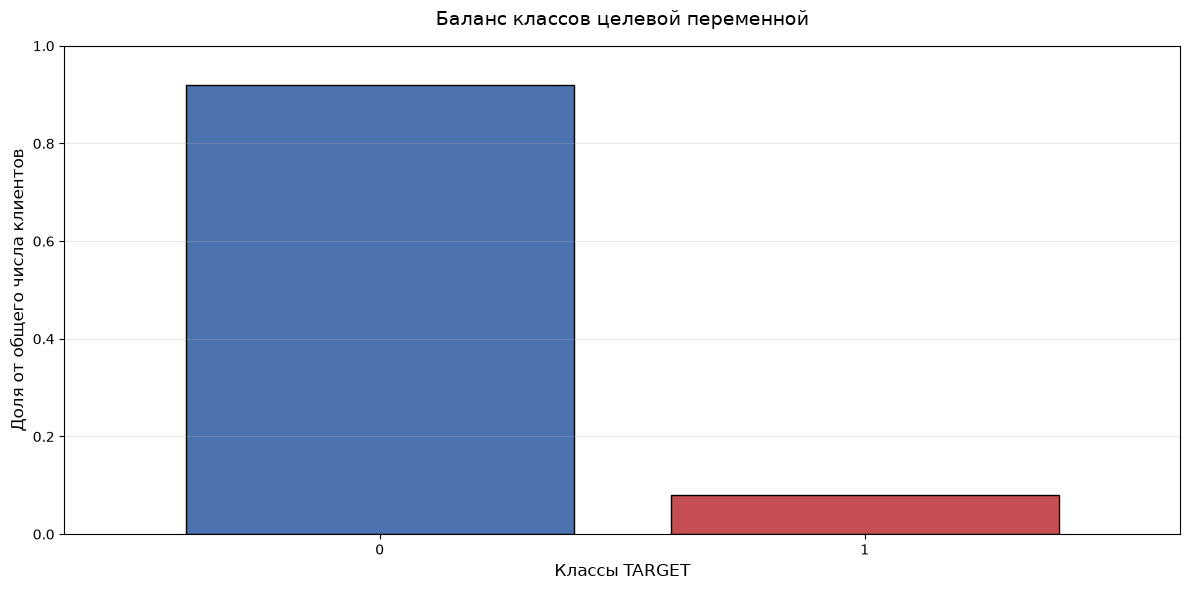

In [113]:
target = df['TARGET'].value_counts(normalize=True)
print(target)

fig, ax = plt.subplots(figsize=(12, 6))
target.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'], edgecolor='black', width=0.8)

ax.set_title('Баланс классов целевой переменной', fontsize=14, pad=15)
ax.set_xlabel('Классы TARGET', fontsize=12)
ax.set_ylabel('Доля от общего числа клиентов', fontsize=12)
ax.set_xticklabels([0, 1], rotation=0)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


Имеется сильный дисбаланс классов: почти 92% значений 0 и только около 8% со значением 1.

**ВЫВОД ПО БЛОКУ:** необходима стратификация при сплите на train/val/test

### Анализ денежных признаков (`AMT_*`)

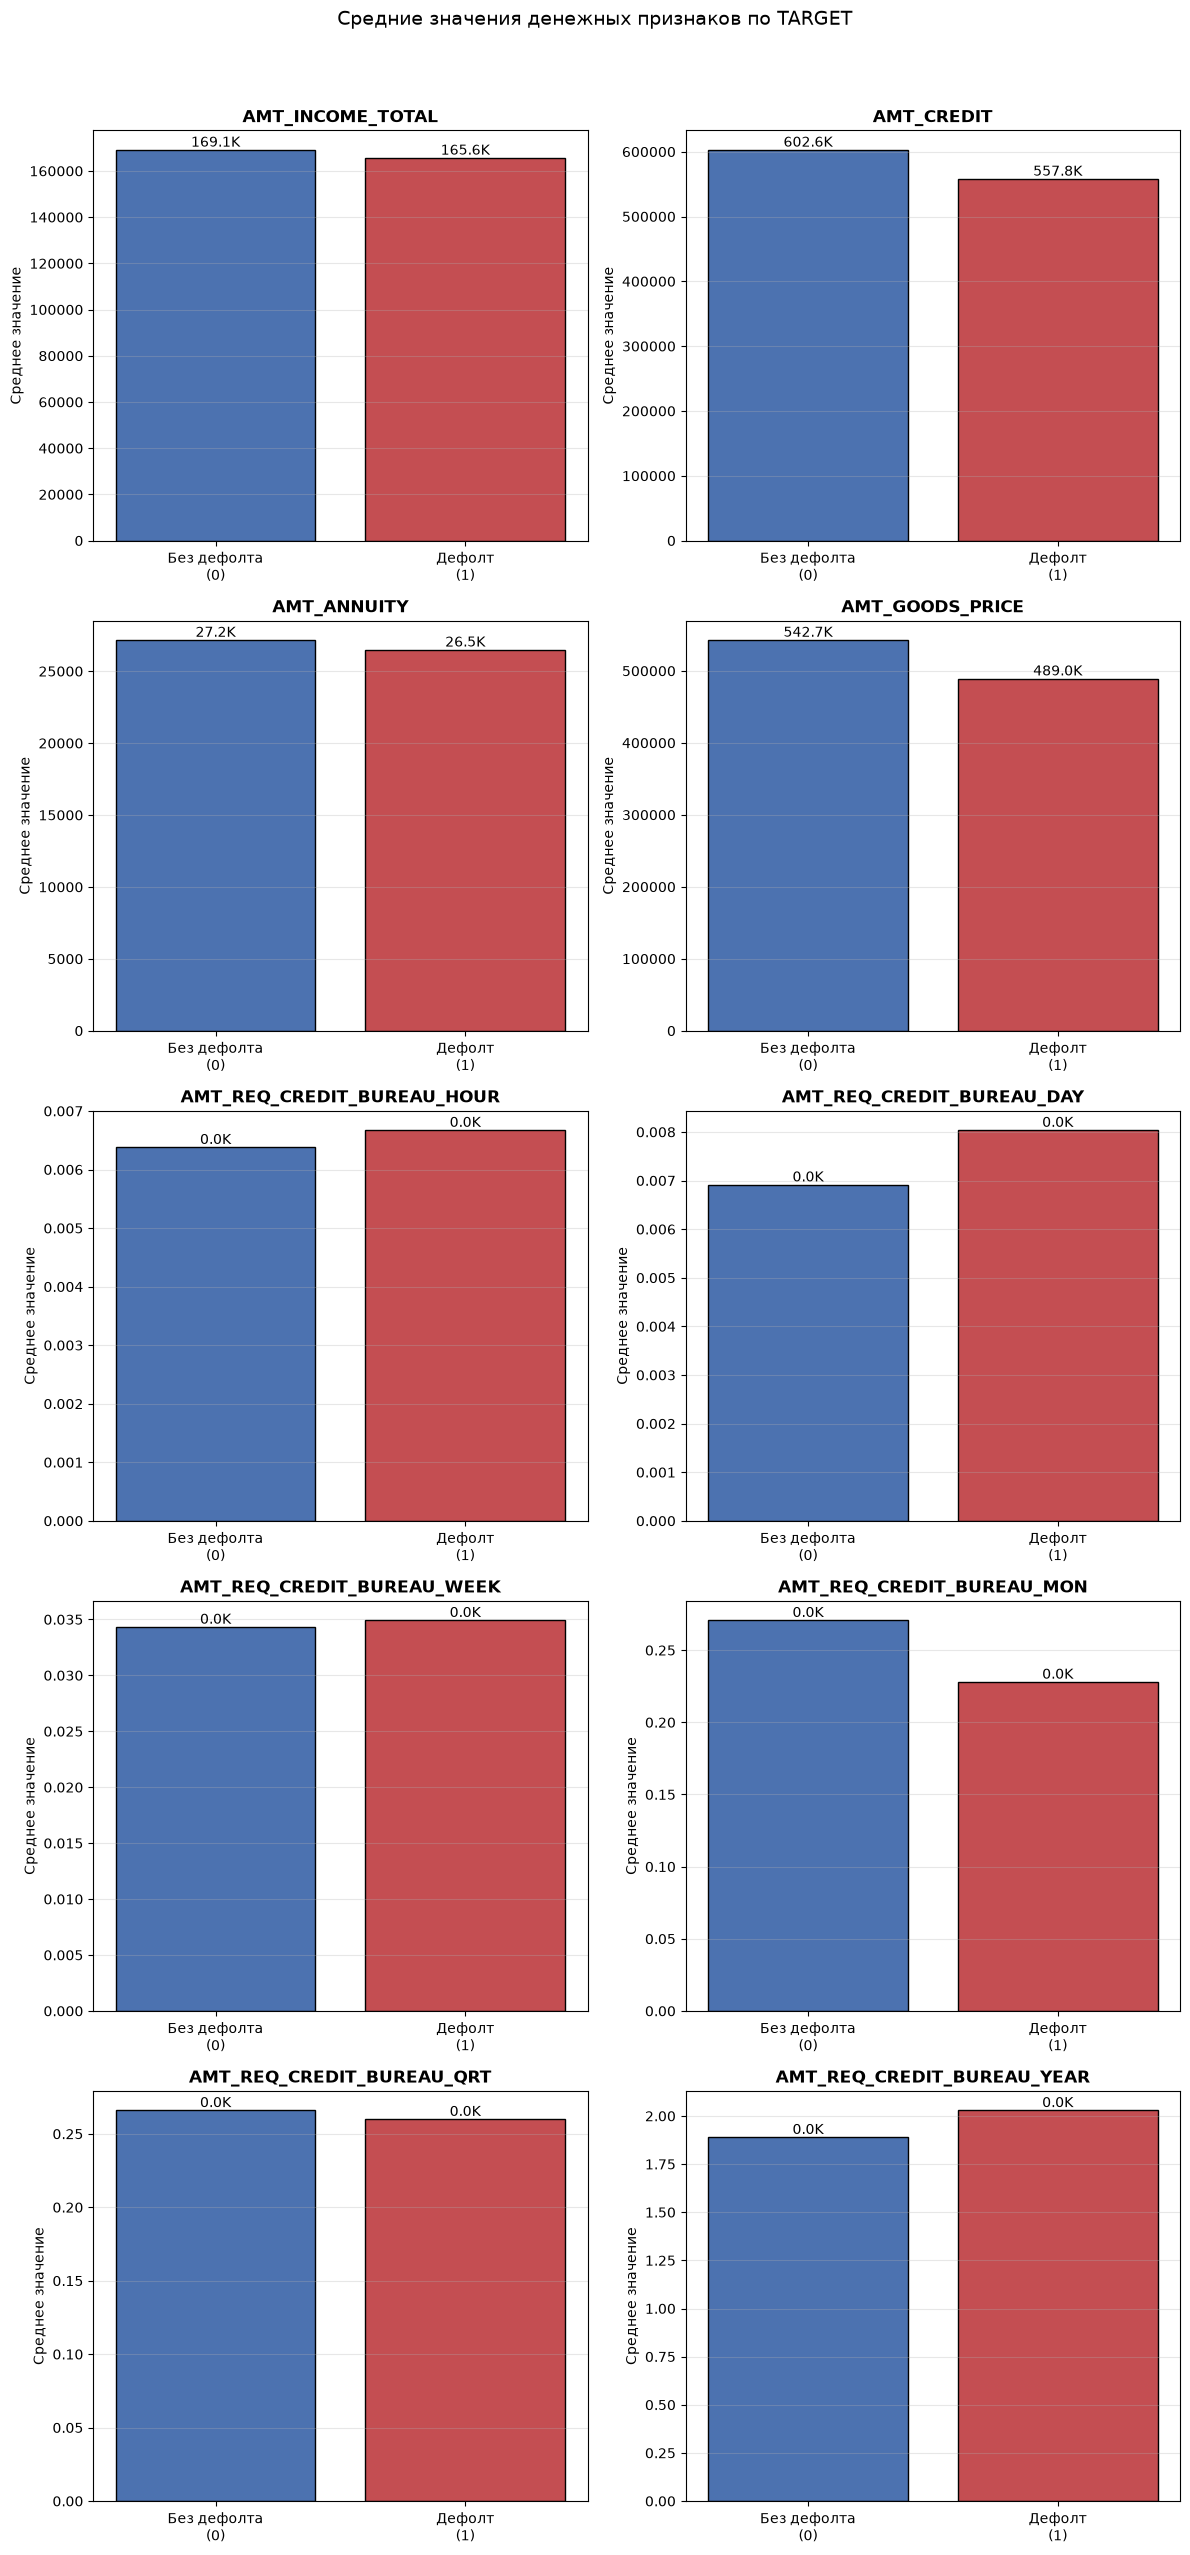

In [124]:
money = feature_groups['money']
money_grouped = df[money + ['TARGET']].groupby('TARGET').mean().T

n = len(money)
ncols = 2
nrows = (n + ncols - 1) // ncols          # округление вверх

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.ravel()                        # ← ключевая строка: 2D → 1D

for ax, col in zip(axes, money):
    vals = money_grouped.loc[col]
    bars = ax.bar(['Без дефолта\n(0)', 'Дефолт\n(1)'],
                  vals.values,
                  color=['#4C72B0', '#C44E52'],
                  edgecolor='black')

    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Среднее значение')
    ax.grid(axis='y', alpha=0.3)

    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                v,
                f'{v/1000:.1f}K',
                ha='center', va='bottom', fontsize=10)

# Если признаков меньше, чем субплотов — скрыть пустые
for ax in axes[len(money):]:
    ax.axis('off')

plt.suptitle('Средние значения денежных признаков по TARGET',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()